# Prédiction du Risque de Diabète par Analyse Clinique et Modèles d'Apprentissage Automatique

## Chargement et pretraitement des données

In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as pps

In [390]:
data = pd.read_csv(r"../data/dataset.csv",index_col=0)

In [391]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [392]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 54.0 KB


In [393]:
data.shape
print(f"Le tableau contient {data.shape[0]} lignes et {data.shape[1]} colonnes ")
nb_lignes_init=data.shape[0]

Le tableau contient 768 lignes et 8 colonnes 


In [394]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Il n'y a pas de valeurs manquantes.

In [395]:
doublons=data.duplicated().sum()
print(doublons)

0


Il n'y a pas de doublons non plus.

## Analyse de la distribution des variables numériques

Matrice de corrélation

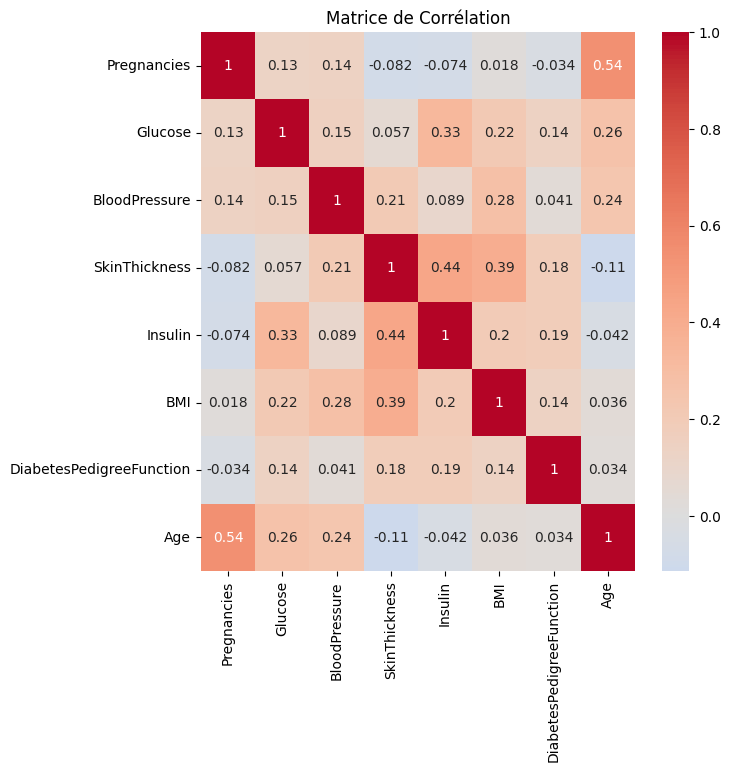

In [396]:
corr_matrix = data.corr()
plt.figure(figsize=(7, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

Hisrogramme des variables numériques:

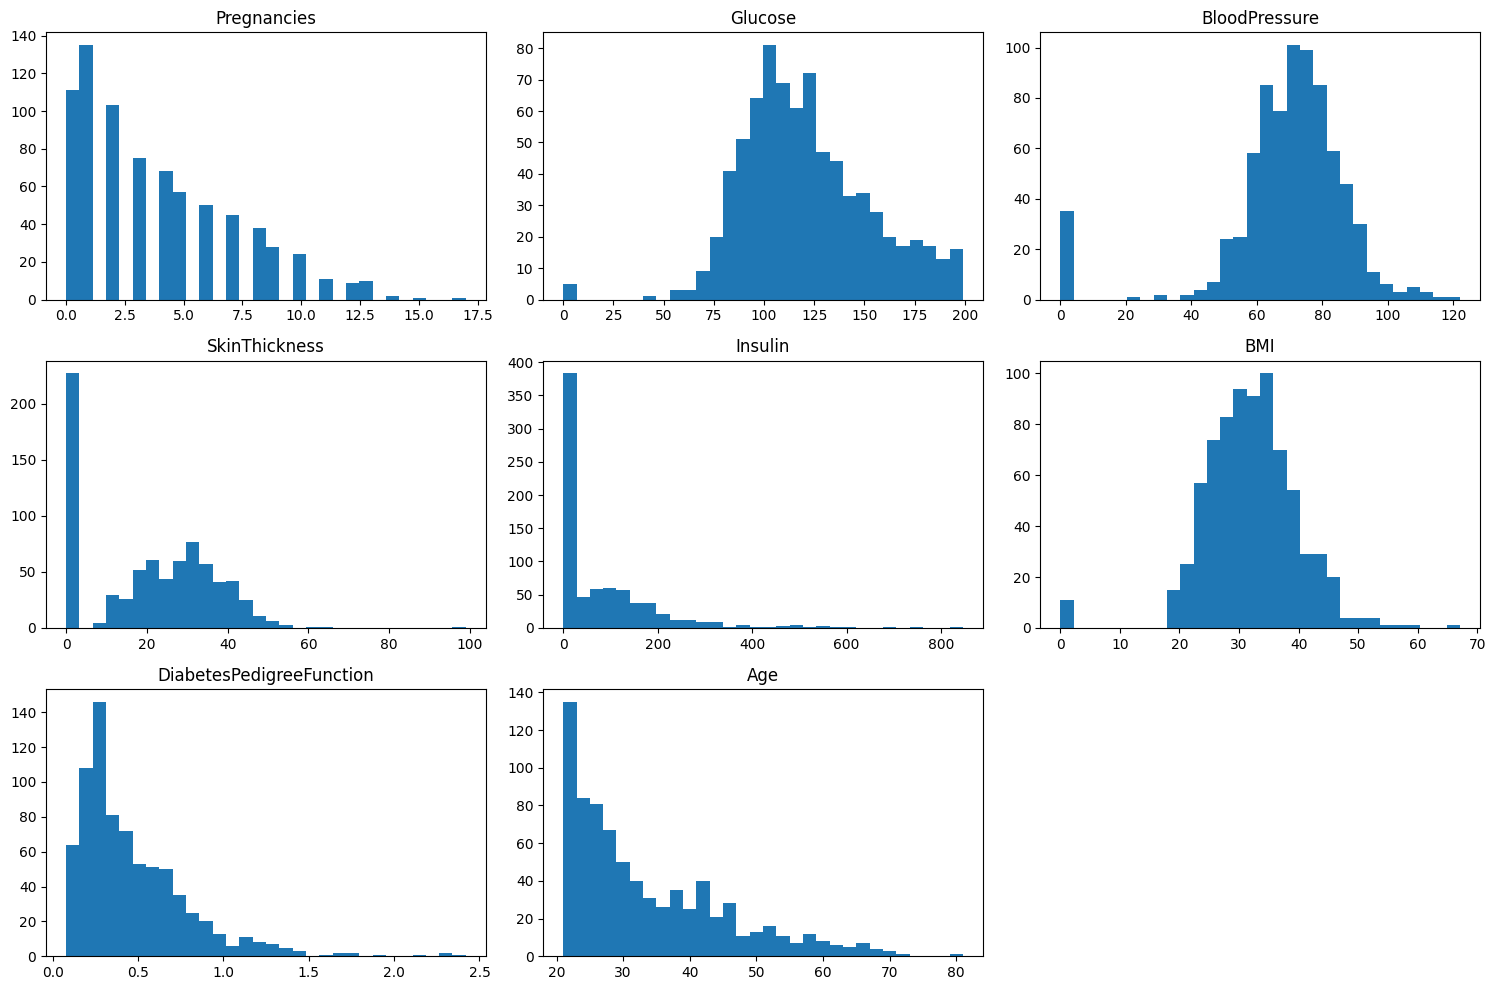

In [397]:
data.hist(bins=30, figsize=(15, 10),grid= False)
plt.tight_layout()
plt.show()

Boite à moustache des données numérique

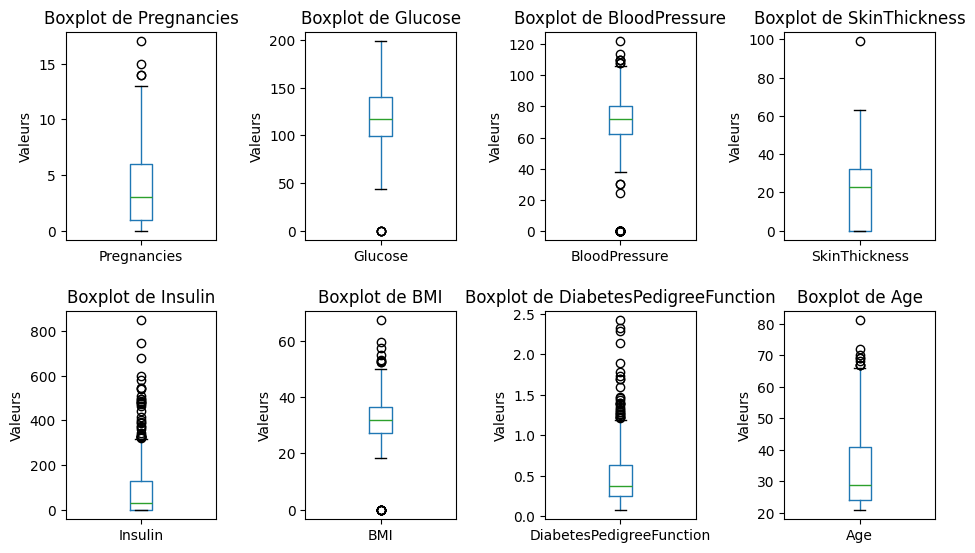

In [398]:
n_cols = len(data.columns)
n_rows = (n_cols + 2) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(10, 3*n_rows)) 
fig.tight_layout(pad=3.0)

axes = axes.flatten()

for i, col in enumerate(data):
    data.boxplot(column=[col], ax=axes[i], grid=False)
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valeurs')

for j in range(n_cols, len(axes)):
    axes[j].axis('off')

plt.show()

### 🔎 1. `Pregnancies`

* **Distribution** fortement **asymétrique à droite** (skewed right).
* Beaucoup de patientes n'ont eu que peu ou pas de grossesses.
* Peut contenir des **valeurs extrêmes** (≥10), à surveiller.

---

### 🔎 2. `Glucose`

* Distribution proche d’une **loi normale tronquée**.
* Pic autour de **100-120**, mais avec un effet d’écrasement à gauche (valeurs à 0 anormales).
* Une valeur de glucose à 0 est **cliniquement impossible** ⇒ **à traiter comme valeur manquante**.

---

### 🔎 3. `BloodPressure`

* Distribution **gaussienne**, centrée vers **70-80 mmHg**.
* Présence de **valeurs nulles** : une pression artérielle à 0 n'est pas possible ⇒ à imputer ou exclure.

---

### 🔎 4. `SkinThickness`

* Distribution très **asymétrique** avec un pic à **0** (impossible biologiquement).
* Ces 0 sont probablement des **valeurs manquantes codées à tort**.

---

### 🔎 5. `Insulin`

* Distribution **très skewed**, avec une énorme densité à **0**.
* Une insuline à 0 est aussi **non physiologique**.
* Beaucoup de données manquantes ou bruitées.

---

### 🔎 6. `BMI`

* Distribution **gaussienne légèrement décalée à droite**.
* Pas de 0 visible ici, donc probablement propre.
* Centrée autour de **30**, ce qui suggère un **surpoids généralisé** dans l’échantillon.

---

### 🔎 7. `DiabetesPedigreeFunction`

* Distribution **asymétrique à droite**, ce qui est logique pour une fonction de prédisposition génétique.
* Valeurs concentrées entre 0 et 0.5, avec quelques outliers.

---

### 🔎 8. `Age`

* Distribution **très skewed** à droite.
* Pic à **21 ans**, majorité des patients jeunes.
* Très peu de personnes âgées dans l’échantillon ⇒ **population probablement biaisée vers la jeunesse**.

---

### 🧠 Synthèse des points d’attention :

| Variable | Problèmes identifiés | Action recommandée |
| ------------------------------------------- | ------------------------------------ | ------------------------------------------- |
| `Glucose`, `BP`, `Insulin`, `SkinThickness` | Valeurs nulles ou aberrantes (`0`) | Imputation ou suppression |
| `Pregnancies`, `Insulin`, `DPF`, `Age` | Skewed / distribution non gaussienne | Transformation (log, box-cox) si nécessaire |
| `BMI` | Distribution correcte | Pas d'action immédiate |

* La fonction data_clean_2 qui se trouve dans le fichier preprocessing nous permet de supprimer les lignes avec les valeur aberrantes.
Les colonnes Insulin et SkinThickness contiennent beaucoup de 0, on les a considéré comme des valeurs manquantes. On ne supprime pas les lignes mais on ne va pas utilisé les colonnes.

In [399]:
data_clean_2=pps.clean_data_2(data)
print(data.shape)
print(data_clean_2.shape)

(768, 8)
(708, 10)


In [400]:
data_clean_2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool
0,6,148,72,35,0,33.6,0.627,50,0,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,0,0
3,1,89,66,23,94,28.1,0.167,21,1,1
5,5,116,74,0,0,25.6,0.201,30,0,0


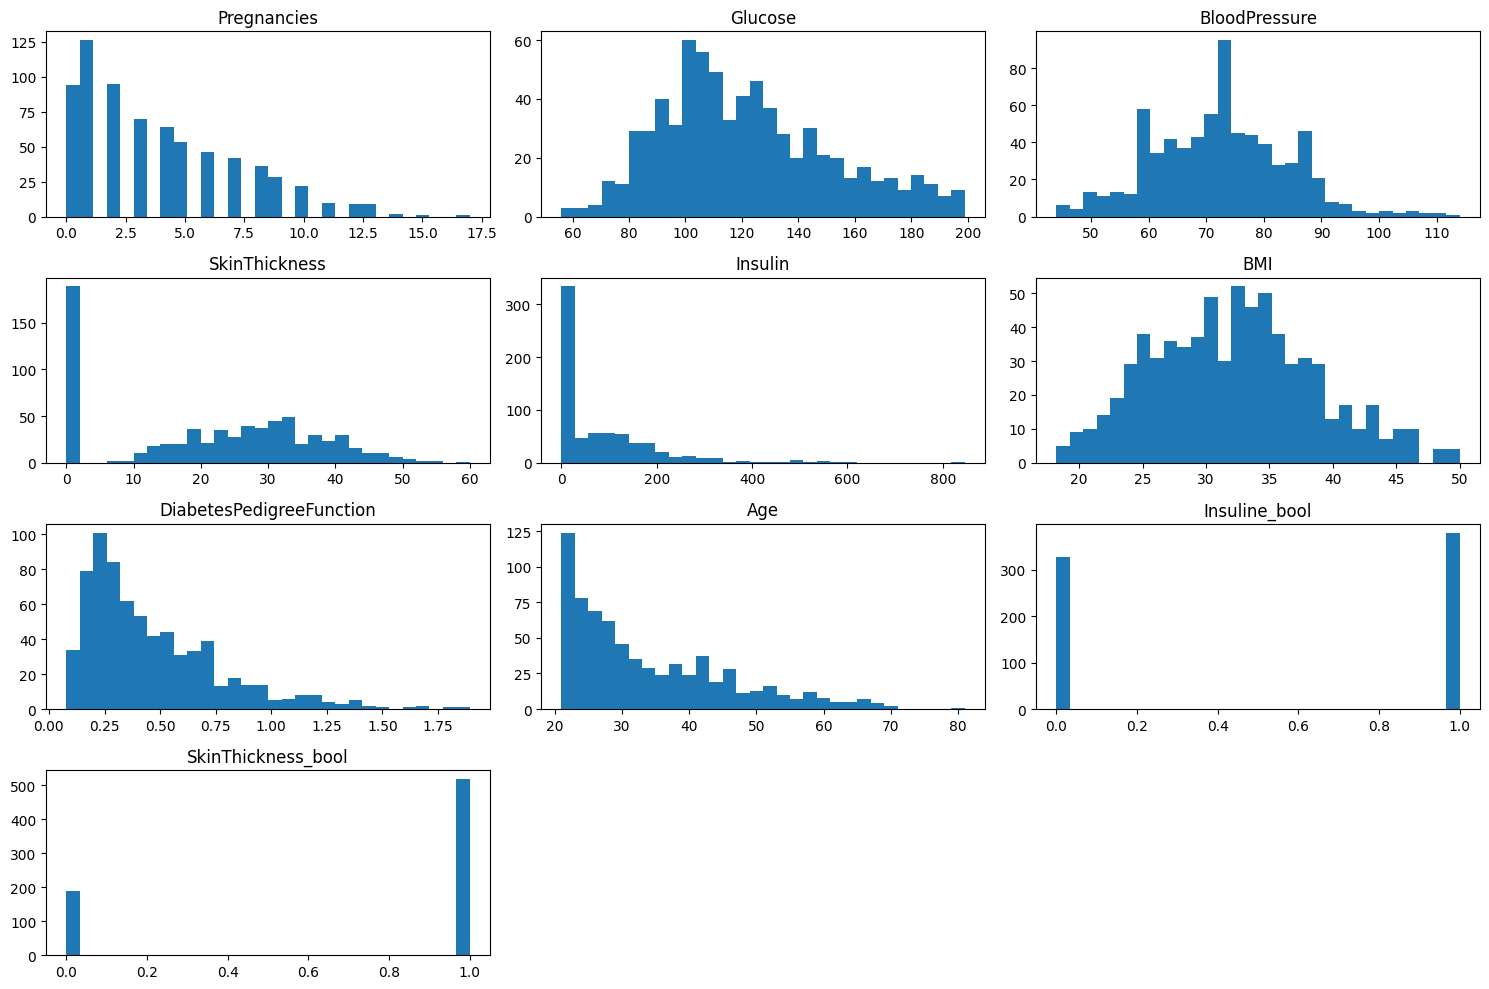

In [401]:
data_clean_2.hist(bins=30, figsize=(15, 10),grid= False)
plt.tight_layout()
plt.show()